In [1]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir,
                 transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)        
        classes = sorted(self.img_labels.iloc[:,1].unique())
        self.class2idx = {c:i for i,c in enumerate(classes)}
        self.img_dir    = img_dir
        self.transform  = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):         
            idx = idx.tolist()

        img_name = self.img_labels.iloc[idx, 0]            # first column = filename
        if not img_name.lower().endswith('.png'):
            img_name = img_name + '.png'
        label = self.img_labels.iloc[idx, 1]            # second column = class
        label = self.class2idx[label]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)

        return image, label

In [2]:

# build a transformation that will be applied to every image
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),    # make all samples the same size
    transforms.RandomHorizontalFlip(),# data‑augmentation
    transforms.ToTensor(),           
    transforms.Normalize(             # zero‑mean, unit‑variance per channel
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std =[0.229,0.224,0.225])
])

In [3]:
df = pd.read_csv('train_labels.csv') 

# shuffle & take 80 % for training
train_df = df.sample(frac=0.8, random_state=42)

# the remainder (20 %) is the “test” / validation set
test_df  = df.drop(train_df.index)

train_df.to_csv('train_split.csv', index=False)
test_df.to_csv('test_split.csv',  index=False)

print("train:", len(train_df), "rows")
print("test :", len(test_df),  "rows")

train: 2880 rows
test : 720 rows


In [4]:

train_csv = './train_labels.csv'  
train_dir = './Train/'            
test_csv  = 'test_split.csv'

train_ds = CustomImageDataset(train_csv, train_dir, transform=train_transform)
test_ds  = CustomImageDataset(test_csv,  train_dir,  transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

<Axes: title={'center': 'Label distribution'}, ylabel='label'>

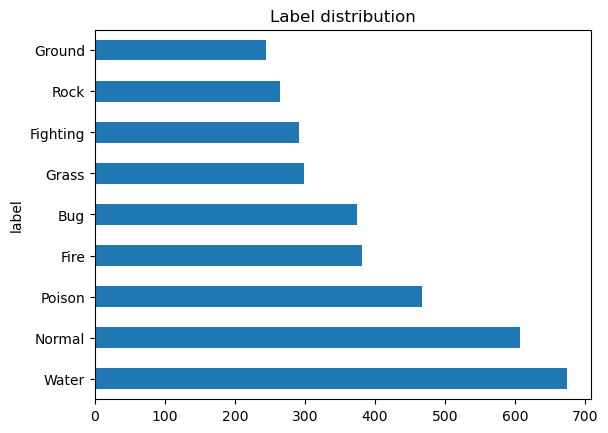

In [5]:
df = pd.read_csv('train_labels.csv')
counts = df['label'].value_counts()
counts.plot(kind='barh', title='Label distribution')


The dataset is unbalanced – the most common class (Water) has nearly three times as many examples as the least common (Ground).

The top three types (Water, Normal, Poison) alone comprise roughly 40 % of the samples.

There are only ~250–300 examples for the rarer types (Rock, Ground, Fighting, Grass).

A naive classifier trained with standard cross‑entropy loss will tend to favour the majority types, achieving deceptively high overall accuracy while performing poorly on the under‑represented classes.

To counteract this we calculate a weight for each class that is inversely proportional to its frequency:

In [6]:
counts = df['label'].value_counts().sort_index()   # ensure consistent ordering
class_weights = 1.0 / counts
class_weights = class_weights / class_weights.sum()  
weights = torch.tensor(class_weights.values, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

In [ ]:
class MLP(nn.Module):
    def __init__(self, num_outputs, num_hiddens, lr=None):
        super().__init__()
        # num_hiddens can be a single int or a list of ints
        if isinstance(num_hiddens, int):
            num_hiddens = [num_hiddens]
        layers = [nn.Flatten()]                    # flatten from C×H×W to vector
        for h in num_hiddens:
            layers.append(nn.LazyLinear(h))        # size inferred on first forward
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.5))
        layers.append(nn.LazyLinear(num_outputs))  # final classification layer
        self.net = nn.Sequential(*layers)

    def forward(self, X):
        return self.net(X)  

In [ ]:
model = MLP(num_outputs=9, num_hiddens=[1024,512]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# helper to compute accuracy on a batch
def batch_accuracy(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

epochs = 10
for epoch in range(1, epochs+1):
    model.train()                        
    running_loss = 0.0
    running_acc  = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)               # forward pass
        loss = criterion(logits, yb)     # weighted cross‑entropy

        optimizer.zero_grad()
        loss.backward()                  # compute gradients
        optimizer.step()                 # update weights

        running_loss += loss.item() * xb.size(0)
        running_acc  += batch_accuracy(logits, yb) * xb.size(0)

    train_loss = running_loss / len(train_ds)
    train_acc  = running_acc  / len(train_ds)

    # validation
    model.eval()                      
    val_loss = 0.0
    val_acc  = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            val_loss += criterion(logits, yb).item() * xb.size(0)
            val_acc  += batch_accuracy(logits, yb) * xb.size(0)
    val_loss /= len(test_ds)
    val_acc  /= len(test_ds)

    print(f"Epoch {epoch:2d} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f}")

Epoch  1 | train loss 26.5722 acc 0.113 | val loss 2.1984 acc 0.090
Epoch  2 | train loss 2.3078 acc 0.083 | val loss 2.1962 acc 0.089
Epoch  3 | train loss 2.2623 acc 0.106 | val loss 2.1944 acc 0.090
Epoch  4 | train loss 2.2184 acc 0.114 | val loss 2.1948 acc 0.138
Epoch  5 | train loss 2.2139 acc 0.154 | val loss 2.1949 acc 0.174
Epoch  6 | train loss 2.2291 acc 0.170 | val loss 2.1925 acc 0.174
Epoch  7 | train loss 2.2203 acc 0.152 | val loss 2.1949 acc 0.174
Epoch  8 | train loss 2.2182 acc 0.186 | val loss 2.1936 acc 0.174
Epoch  9 | train loss 2.2164 acc 0.177 | val loss 2.1972 acc 0.171
Epoch 10 | train loss 2.2192 acc 0.184 | val loss 2.1973 acc 0.172
Epoch 11 | train loss 2.2187 acc 0.172 | val loss 2.1974 acc 0.172
Epoch 12 | train loss 2.2092 acc 0.171 | val loss 2.1976 acc 0.171
Epoch 13 | train loss 2.2236 acc 0.151 | val loss 2.1973 acc 0.172
Epoch 14 | train loss 2.2348 acc 0.188 | val loss 2.1974 acc 0.172
Epoch 15 | train loss 2.2304 acc 0.187 | val loss 2.1973 acc 

In [ ]:
# --- evaluation on validation set ------------------------------------------
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:     
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_targets.append(yb.cpu())

all_preds   = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

# overall accuracy
accuracy = (all_preds == all_targets).float().mean().item()
print(f"validation accuracy: {accuracy:.4f}")

# per‑class metrics
type_names = sorted(train_ds.class2idx, key=lambda k: train_ds.class2idx[k])
print(classification_report(all_targets, all_preds,
                            target_names=type_names))

# confusion matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=type_names,
            yticklabels=type_names, cmap="Blues")
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Confusion matrix")
plt.show()

NameError: name 'val_loader' is not defined

In [ ]:
idx2class = {v:k for k,v in train_ds.class2idx.items()}
test_ids = [f.split('.png')[0] for f in os.listdir('Test') if f.endswith('.png')]

class ImageOnlyDataset(Dataset):
    def __init__(self, ids, img_dir, transform=None):
        self.ids = ids
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        name = self.ids[idx]
        path = os.path.join(self.img_dir, name + '.png')
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

test_ds = ImageOnlyDataset(test_ids, 'Test/', transform=val_transform)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# prediction loop adjusts 
preds = []
with torch.no_grad():
    for xb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.extend(logits.argmax(1).cpu().tolist())

assert len(preds) == len(test_ids)

# map back to strings and write submission file
out_df = pd.DataFrame({
    'Id': test_ids,
    'label': [idx2class[i] for i in preds]
})
out_df.to_csv('submission.csv', index=False)
print('wrote', len(out_df), 'predictions to submission.csv')

wrote 900 predictions to submission.csv
